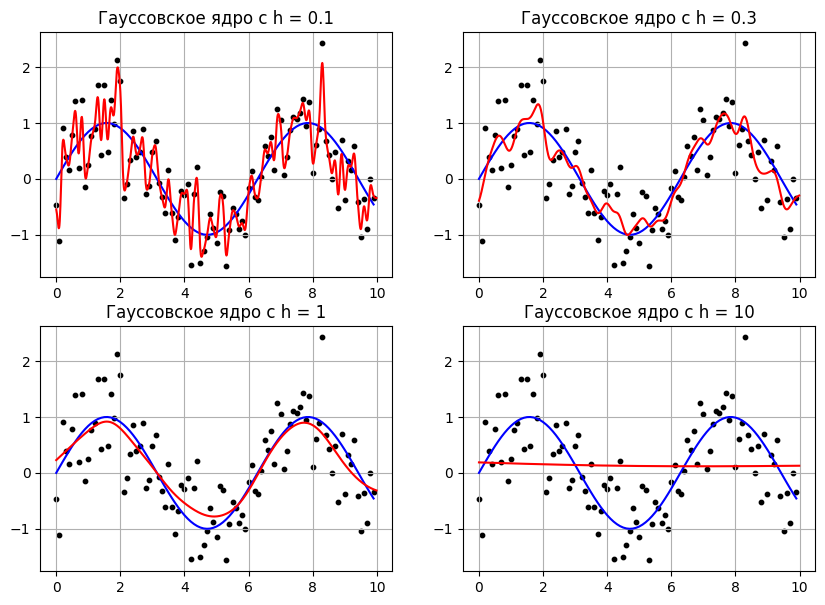

In [6]:
# Аппроксимация данных ядерным сглаживанием

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 10, 0.1)           # отсчеты для исходного сигнала
x_est = np.arange(0, 10, 0.01)      # отсчеты, где производится восстановление функции
N = len(x)
y_sin = np.sin(x)
y = y_sin + np.random.normal(0, 0.5, N)

# аппроксимация ядерным сглаживанием
h = 1.0     # при окне меньше 0.1 для финитных ядер будут ошибки

K = lambda r: np.exp(-2 * r * r)        # гауссовское ядро
# K = lambda r: np.abs(1 - r) * bool(r <= 1)        # треугольное ядро
# K = lambda r: bool(r <= 1)        # прямоугольное ядро

ro = lambda xx, xi: np.abs(xx - xi)     # метрика
w = lambda xx, xi: K(ro(xx, xi) / h)    # веса

plt.figure(figsize=(10, 7))
plot_number = 0

for h in [0.1, 0.3, 1, 10]:
    y_est = []
    for xx in x_est:
        ww = np.array([w(xx, xi) for xi in x])
        yy = np.dot(ww, y) / sum(ww)            # формула Надарая-Ватсона
        y_est.append(yy)

    plot_number += 1
    plt.subplot(2, 2, plot_number)

    plt.scatter(x, y, color='black', s=10)
    plt.plot(x, y_sin, color='blue')
    plt.plot(x_est, y_est, color='red')
    plt.title(f"Гауссовское ядро с h = {h}")
    plt.grid()

plt.show()

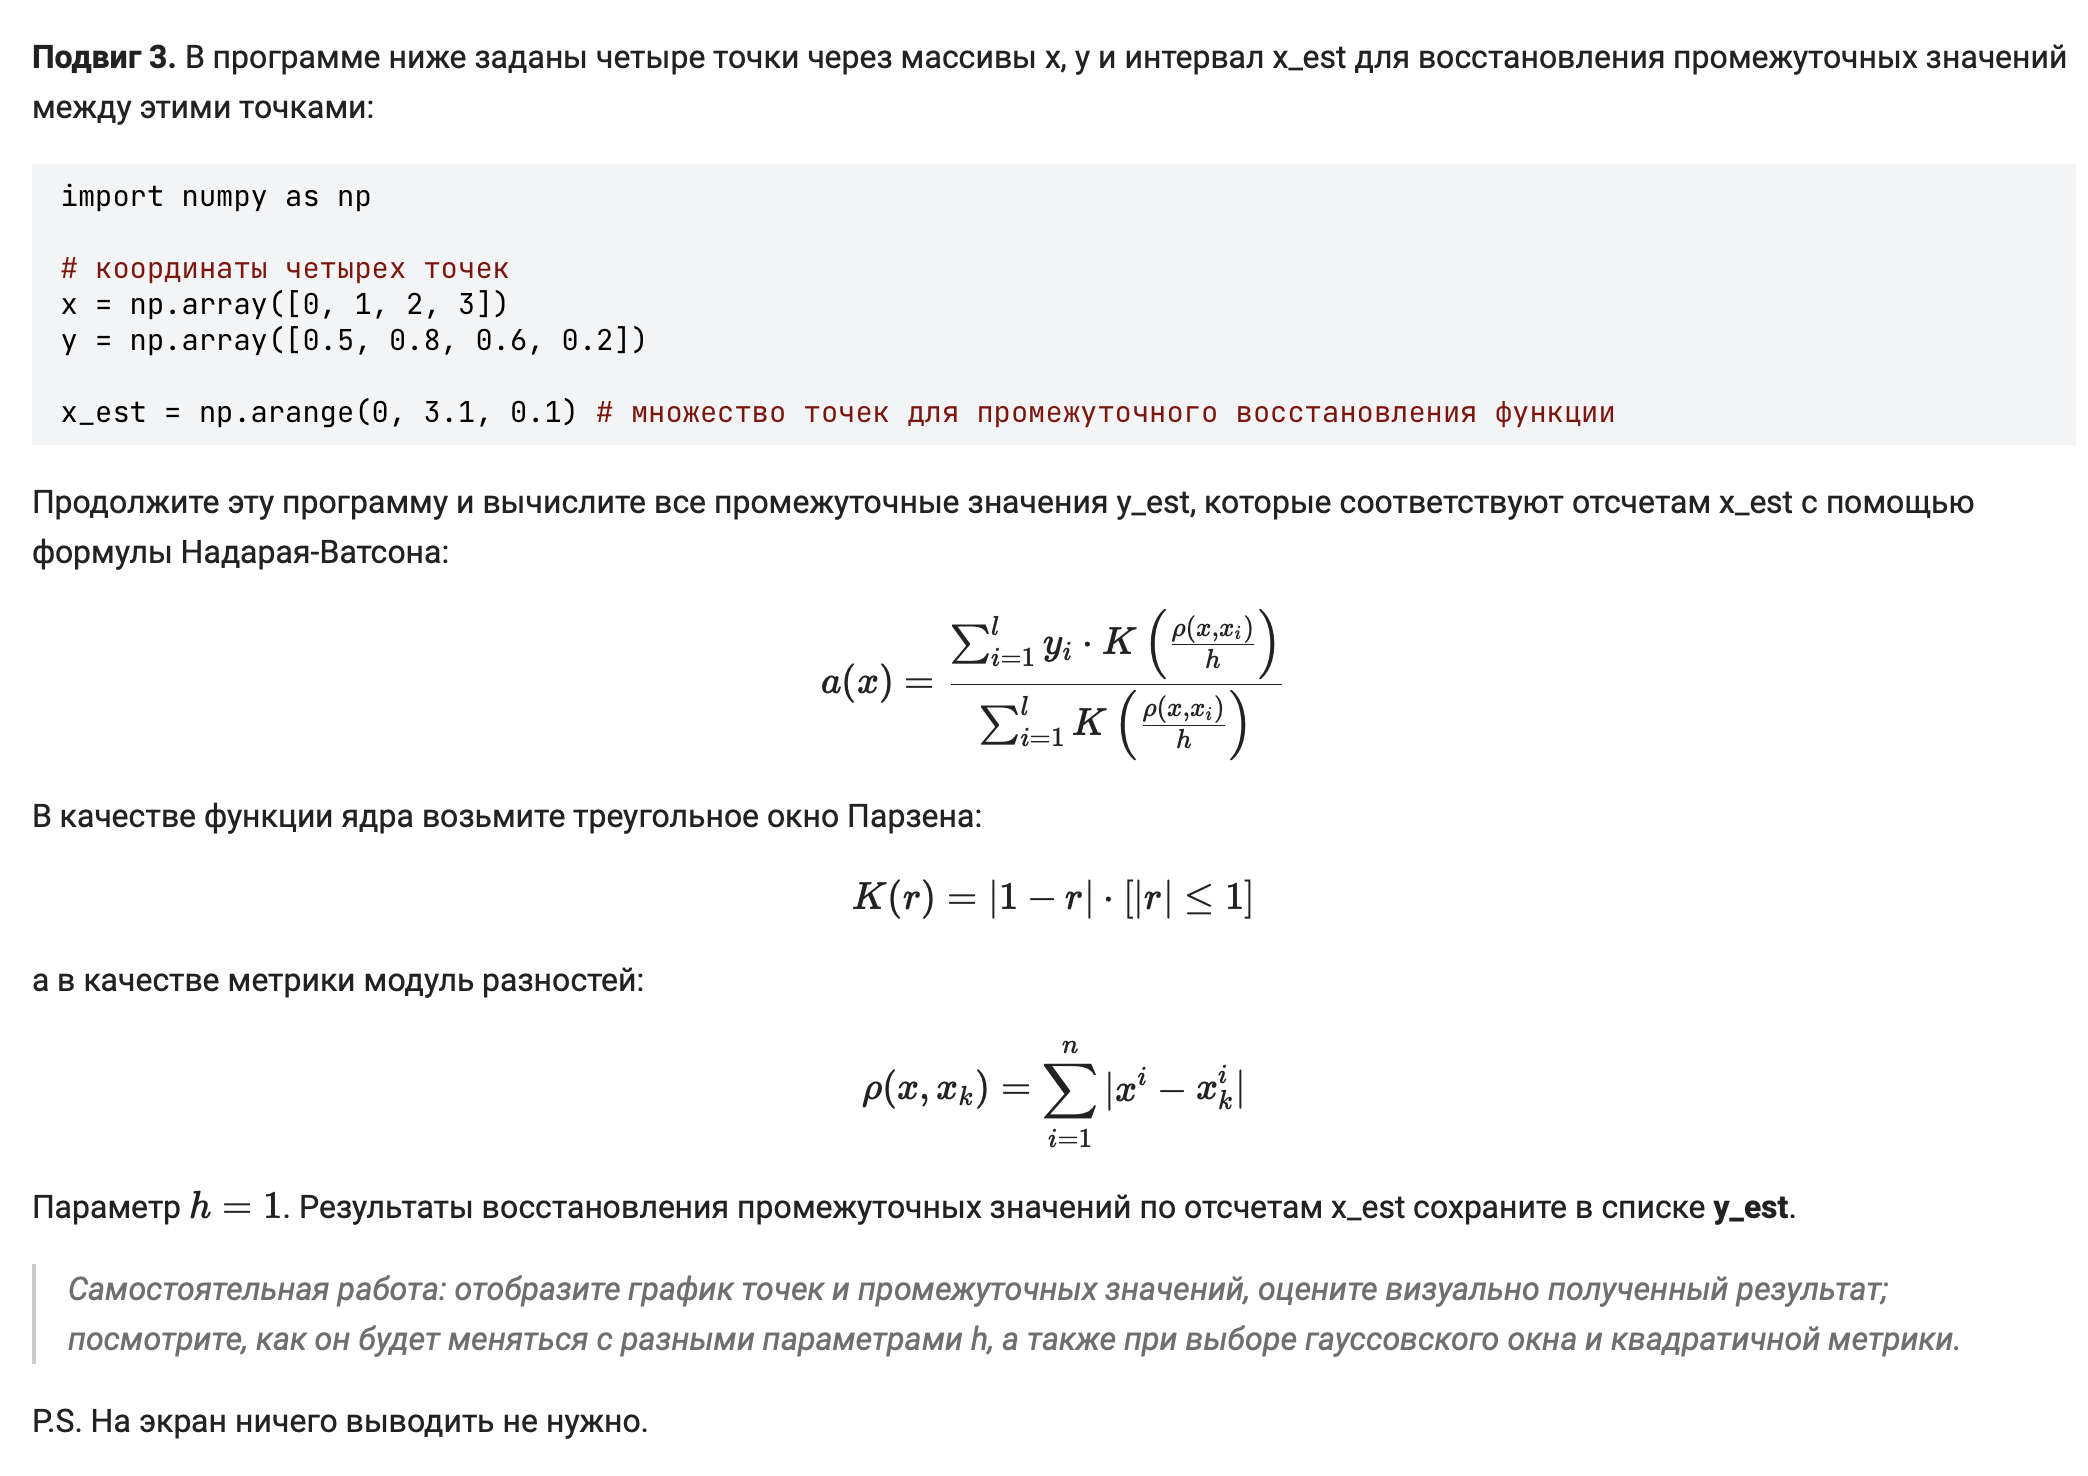

/var/folders/cl/r93zvffj0sz_6qfhc44pj6mr0000gn/T/ipykernel_27192/3858158041.py:25: RuntimeWarning: invalid value encountered in divide
  y_est = wind @ y / np.sum(wind, axis=1)


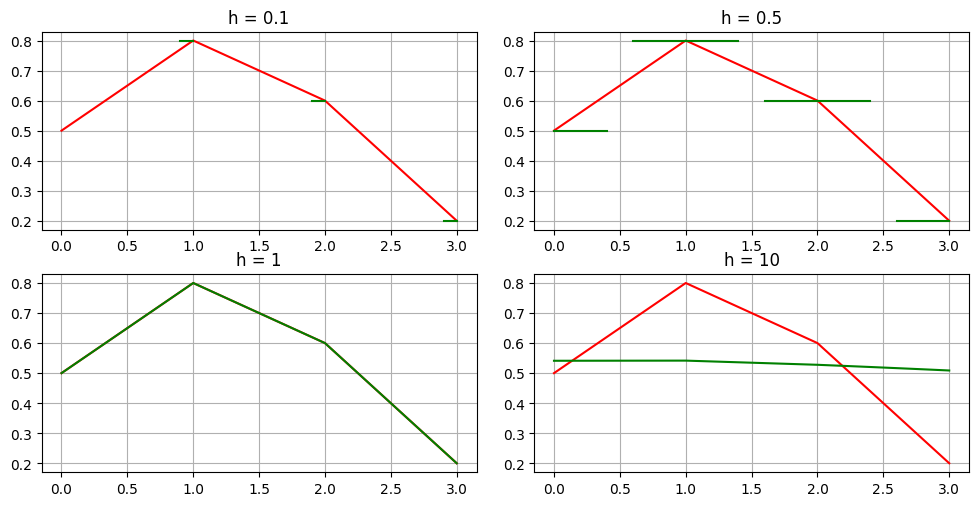

In [57]:
import numpy as np
from matplotlib import pyplot as plt

# координаты четырех точек
x = np.array([0, 1, 2, 3])
y = np.array([0.5, 0.8, 0.6, 0.2])

x_est = np.arange(0, 3.1, 0.1) # множество точек для промежуточного восстановления функции

# здесь продолжайте программу
ro = lambda xx, xi: (xx - xi).sum()

# K = lambda r: np.exp(-2 * r * r)        # гауссовское ядро
K = lambda r: np.abs(1 - r) * (np.abs(r) <= 1)        # треугольное ядро
# K = lambda r: (np.abs(r) <= 1)        # прямоугольное ядро

fig, axes = plt.subplots(2, 2)
fig.set_figwidth(10)
fig.set_figheight(5)
fig.tight_layout()
n_plots = 0
for i, h in enumerate([0.1, 0.5, 1, 10]):
    dist = np.abs(x_est[:, np.newaxis] - x[np.newaxis, :])
    wind = K(dist / h)
    y_est = wind @ y / np.sum(wind, axis=1)

    axes[n_plots][i % 2].plot(x, y, c='red')
    axes[n_plots][i % 2].plot(x_est, y_est, c='green')
    axes[n_plots][i % 2].grid(True)
    axes[n_plots][i % 2].set_title(f"h = {h}")

    if i == 1: n_plots = 1

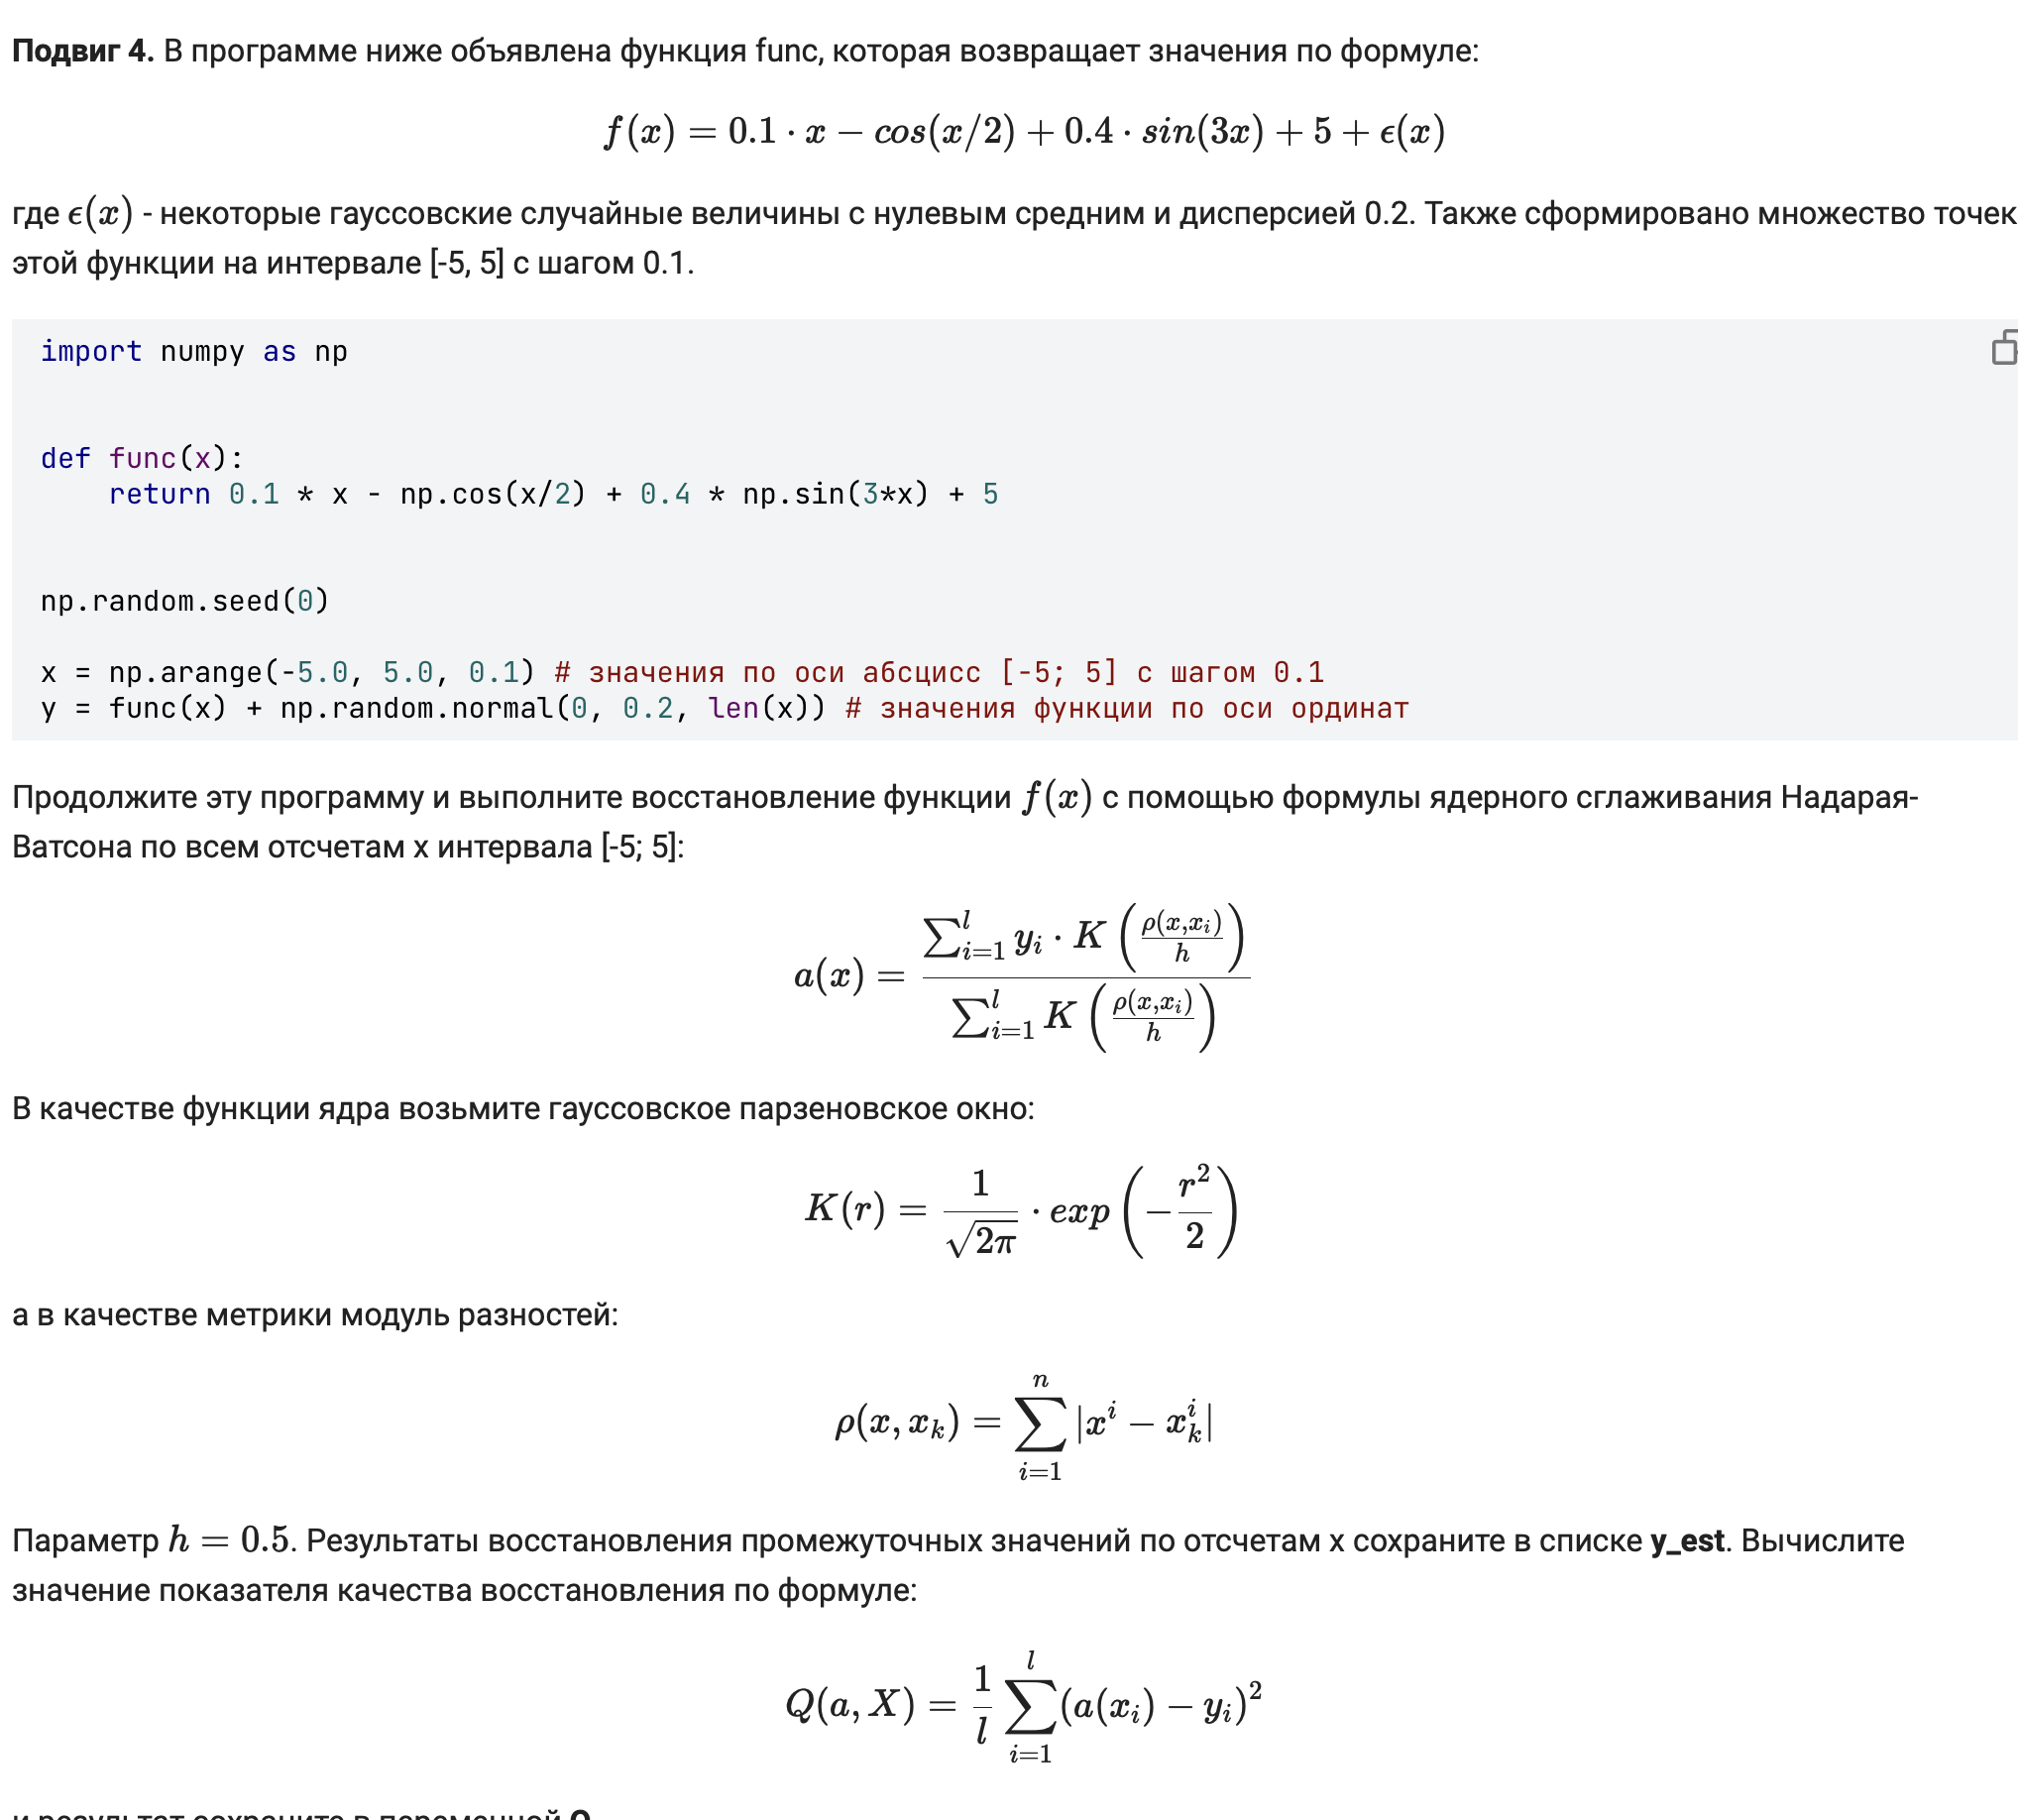
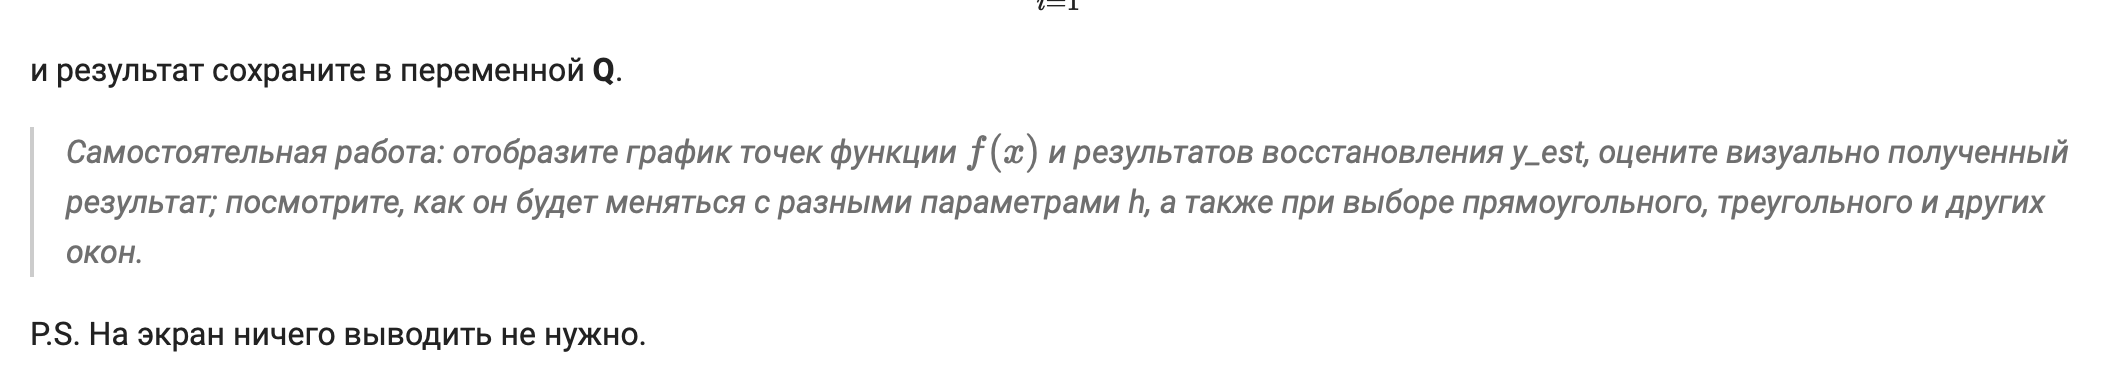

In [67]:
import numpy as np


def func(x):
    return 0.1 * x - np.cos(x/2) + 0.4 * np.sin(3*x) + 5


np.random.seed(0)

x = np.arange(-5.0, 5.0, 0.1) # значения по оси абсцисс [-5; 5] с шагом 0.1
y = func(x) + np.random.normal(0, 0.2, len(x)) # значения функции по оси ординат

# здесь продолжайте программу
h = 0.5
dist = np.abs(x[:, np.newaxis] - x[np.newaxis, :])
K = 1/(2*np.pi) ** 0.5 * np.exp(-(dist / h)**2/2)
y_est = K @ y / np.sum(K, axis=1)
Q = np.mean((y_est - y) ** 2)
Q

np.float64(0.07226677375622806)

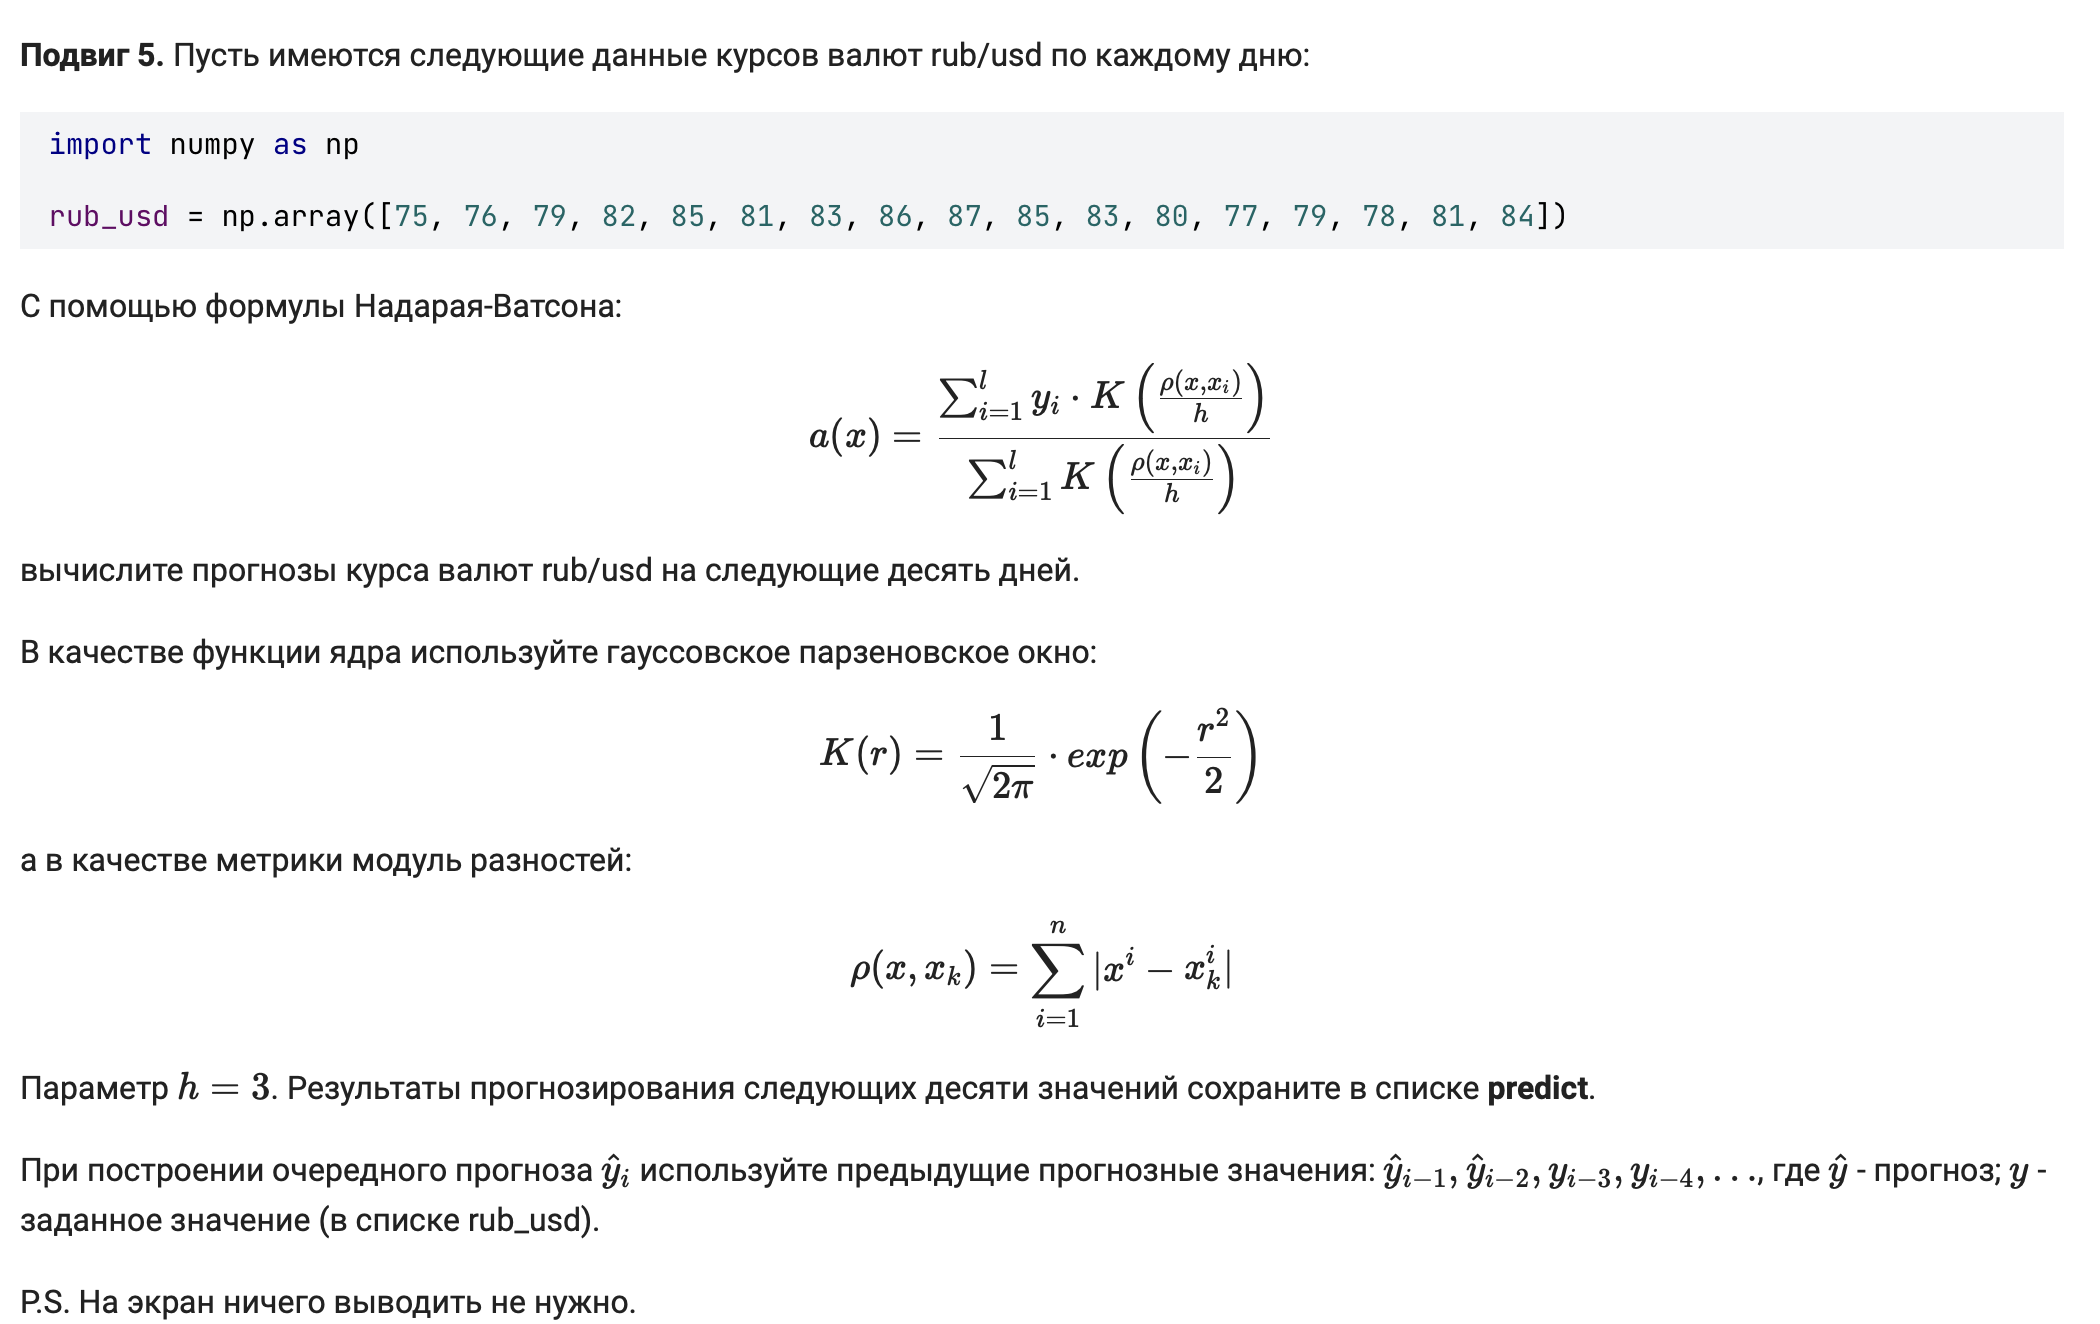

In [99]:
import numpy as np

rub_usd = np.array([75, 76, 79, 82, 85, 81, 83, 86, 87, 85, 83, 80, 77, 79, 78, 81, 84])
days = np.arange(0, len(rub_usd), 1)

# здесь продолжайте программу
h = 3
N = 10

predict = np.array([])
for i in range(N):
    day = np.array([days[-1] + 1] * len(rub_usd))
    dist = np.abs(day - days) / h
    K = 1 / (2*np.pi) ** 0.5 * np.exp(-dist ** 2 / 2)
    pred = K @ rub_usd / K.sum()
    predict = np.append(predict, pred)

    days = np.append(days, days[-1] + 1)
    rub_usd = np.hstack([rub_usd, predict[i]])
rub_usd, predict

(array([75.        , 76.        , 79.        , 82.        , 85.        ,
        81.        , 83.        , 86.        , 87.        , 85.        ,
        83.        , 80.        , 77.        , 79.        , 78.        ,
        81.        , 84.        , 80.81526358, 81.00609743, 81.12699379,
        81.18358804, 81.20027875, 81.20015404, 81.19663892, 81.19445283,
        81.19384632, 81.19393969]),
 array([80.81526358, 81.00609743, 81.12699379, 81.18358804, 81.20027875,
        81.20015404, 81.19663892, 81.19445283, 81.19384632, 81.19393969]))